# 프로젝트 개요 

> * 본 프로젝트는 서울 주요 대학가 주변의 월세 실거래 데이터를 활용하여 지역별 월세 가격 분포를 분석함.
> * 면적·건축년도·층수 등의 요소가 월세에 미치는 영향을 확인하고자 함. 
> * 목표 : 머신러닝 기반 월세 예측 모델을 구축하여 대학생들의 주거 선택에 도움을 주는 것이 목표임.


## 문제정의 


> 부동산 플랫폼 다방의 조사에 따르면, 서울 주요 대학가 원룸의 평균 월세는 지속적으로 상승하고 있다.
최근 조사 기준, 서울 주요 대학가 원룸의 평균 월세는 60만 원 이상이며, 전년 대비 약 6.1% 상승한 것으로 나타났다.

> 특히 대학별 월세 수준에도 차이가 나타났는데, 이화여대 인근은 평균 74.1만 원으로 가장 높았으며, 연세대 64.3만 원, 한국외국어대 63.1만 원, 성균관대 62.5만 원 순으로 조사되었다.<br>

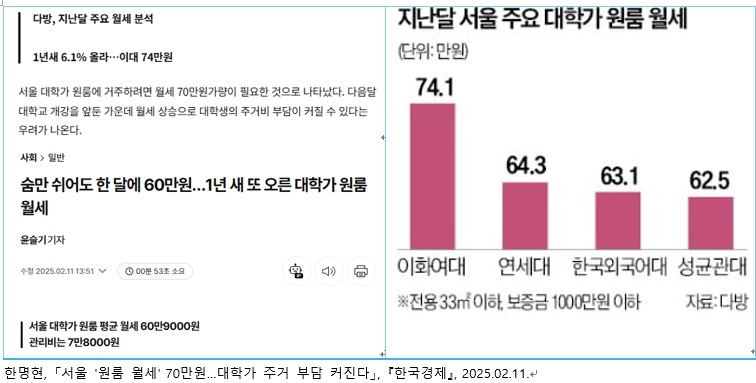

<br>

> 이처럼 대학가별 월세 격차와 지속적인 가격 상승은 대학생들의 주거비 부담을 높이고 있으며, 지역별 주거 비용을 비교·분석할 수 있는 데이터 기반 정보의 필요성이 커지고 있다.

## 기존 솔루션 차별성

| 비교 항목 | 기존 부동산 플랫폼 (직방, 다방, 네이버 부동산) | 본 프로젝트 |
|---|---|---|
| 정보 제공 방식 | 개별 매물 중심 조회 | 지역별 월세 데이터 종합 분석 |
| 가격 비교 방식 | 사용자가 직접 여러 매물 비교 | 대학가별 평균·분포 자동 비교 |
| 가격 판단 기준 | 시세 판단 기준 부족 | 데이터 기반 적정 월세 수준 제시 |
| 분석 가능 요소 | 단순 필터링 (가격, 면적 등) | 면적, 건축년도, 층수 등 영향 요인 분석 |
| 예측 기능 | 없음 | 입력 조건 기반 월세 예측 가능 |
| 대학생 맞춤성 | 일반 사용자 대상 | 대학생 주거 선택 지원에 초점 |
| 활용 목적 | 매물 탐색 | 합리적 지역 선택 및 예산 계획 지원 |

> 기존 부동산 플랫폼은 월세 매물을 확인할 수 있도록 다양한 정보를 제공하지만, 대부분 개별 매물 조회 중심으로 구성되어 있어 지역별 월세 수준을 종합적으로 비교하거나 객관적인 가격 분포를 파악하기 어렵다는 한계가 있다. 또한 사용자가 직접 여러 매물을 비교해야 하므로, 특정 지역의 평균적인 시세나 적정 가격을 판단하기 쉽지 않다.

> 본 프로젝트는 기존 플랫폼이 **“어떤 매물이 있는지 보여주는 서비스”**라면, **“어느 지역이 예산과 조건에 더 적합한지 데이터를 기반으로 판단할 수 있도록 돕는 분석 서비스”**라는 점에서 차별성이 있다.

> 특히 서울 주요 대학가 주변의 월세 데이터를 종합적으로 분석하여 지역별 가격 수준과 분포를 비교하고, 면적·건축년도·층수·대학까지 거리 등의 다양한 요인이 월세에 미치는 영향을 함께 분석한다. 더 나아가 머신러닝 기반의 월세 예측 모델을 통해 사용자가 원하는 조건을 입력하면 예상 월세를 확인할 수 있도록 하여, 대학생들의 합리적인 주거 선택과 예산 계획 수립을 지원하는 **데이터 기반 의사결정 도구**를 목표로 한다.

## 기대효과

1. **대학생의 합리적인 주거 선택 지원**  
   서울 주요 대학가의 지역별 월세 수준과 가격 분포를 비교할 수 있어, 대학생들이 자신의 예산에 맞는 자취 지역을 보다 객관적으로 선택할 수 있다.

2. **월세 가격 결정 요인 분석 및 예측 가능**  
   전용면적, 보증금, 건축년도, 대학까지 거리 등 다양한 요인이 월세에 미치는 영향을 분석하고, 이를 기반으로 예상 월세를 예측하여 적정 가격 판단과 예산 계획 수립에 활용할 수 있다.

3. **향후 주거 추천 서비스로의 확장 가능성**  
   구축한 분석 결과와 예측 모델은 대학생 대상 자취방 추천 서비스, 대학가 월세 비교 플랫폼, 예산 기반 지역 추천 시스템 등 다양한 데이터 기반 부동산 서비스의 기초 자료로 활용될 수 있다.

In [2]:
# 헤더 모음 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

import warnings

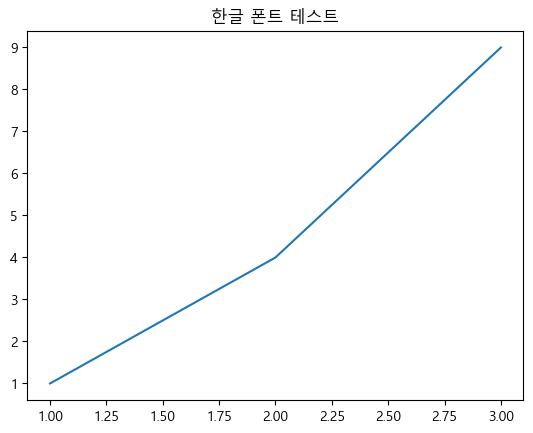

In [3]:
### 한국어 폰트 설정 
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 확인용 테스트
plt.title("한글 폰트 테스트")
plt.plot([1, 2, 3], [1, 4, 9])
plt.show()

## 데이터 확보 및 전처리 

In [4]:
import pandas as pd
# 연립다세대와 오피스텔 데이터 컬럼 구조가 똑같지 않을 수 있으므로,
# 모든 컬럼을 유지한 채 병합하고 없는 값은 NaN으로 채운다.
df1 = pd.read_csv("연립다세대(전월세).csv", encoding='cp949')
df2 = pd.read_csv("오피스텔(전월세).csv", encoding='cp949')

print("연립다세대 shape:", df1.shape
      , " / 오피스텔 shape:", df2.shape)

cols1 = set(df1.columns)
cols2 = set(df2.columns)
common_cols = sorted(cols1 & cols2)
only_in_df1 = sorted(cols1 - cols2)
only_in_df2 = sorted(cols2 - cols1)

print("연립다세대 공통/비공통 컬럼 개수:", len(common_cols), " / ", len(only_in_df1), len(only_in_df2))
print("연립다세대에만 있는 컬럼:", only_in_df1)
print("오피스텔에만 있는 컬럼:", only_in_df2)

load_df = pd.concat([df1, df2], ignore_index=True, sort=False)
df = load_df.copy()

print("load_df shape:", load_df.shape)
load_df.head()

C:\Users\yujaerim\AppData\Local\Temp\ipykernel_3972\1393940653.py:4: DtypeWarning: Columns (0: 종전계약 월세(만원)) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("연립다세대(전월세).csv", encoding='cp949')


연립다세대 shape: (133808, 21)  / 오피스텔 shape: (92367, 20)
연립다세대 공통/비공통 컬럼 개수: 19  /  2 1
연립다세대에만 있는 컬럼: ['건물명', '주택유형']
오피스텔에만 있는 컬럼: ['단지명']
load_df shape: (226175, 22)


,NO,시군구,번지,본번,부번,건물명,전월세구분,전용면적(㎡),계약년월,계약일,...,층,건축년도,도로명,계약기간,계약구분,갱신요구권 사용,종전계약 보증금(만원),종전계약 월세(만원),주택유형,단지명
0,1,서울특별시 강남구 개포동,1219-3,1219,3,장원,전세,53.42,202605,8,...,2,2013.0,개포로22길 36,202606~202806,신규,-,NaN,NaN,연립다세대,NaN
1,2,서울특별시 강남구 역삼동,728-51,728,51,다올하우스,전세,29.69,202605,8,...,3,2018.0,테헤란로32길 53,202607~202807,신규,-,NaN,NaN,연립다세대,NaN
2,3,서울특별시 중구 신당동,432-1935,432,1935,남산빌라1차,전세,58.19,202605,8,...,2,2003.0,동호로11아길 14,202605~202805,신규,-,NaN,NaN,연립다세대,NaN
3,4,서울특별시 강남구 개포동,1221-10,1221,10,셍상스1,전세,21.76,202605,8,...,2,1996.0,논현로16길 20-3,202608~202707,갱신,사용,"10,400",0,연립다세대,NaN
4,5,서울특별시 종로구 혜화동,22-88,22,88,뉴파인빌2(22-88),월세,27.96,202605,8,...,4,2018.0,혜화로6길 48,202606~202806,신규,-,NaN,NaN,연립다세대,NaN


In [5]:
print(load_df.columns)
print(load_df.info())

Index(['NO', '시군구', '번지', '본번', '부번', '건물명', '전월세구분', '전용면적(㎡)', '계약년월', '계약일',
       '보증금(만원)', '월세금(만원)', '층', '건축년도', '도로명', '계약기간', '계약구분', '갱신요구권 사용',
       '종전계약 보증금(만원)', '종전계약 월세(만원)', '주택유형', '단지명'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 226175 entries, 0 to 226174
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   NO            226175 non-null  int64  
 1   시군구           226175 non-null  str    
 2   번지            226175 non-null  str    
 3   본번            226175 non-null  int64  
 4   부번            226175 non-null  int64  
 5   건물명           133807 non-null  str    
 6   전월세구분         226175 non-null  str    
 7   전용면적(㎡)       226175 non-null  float64
 8   계약년월          226175 non-null  int64  
 9   계약일           226175 non-null  int64  
 10  보증금(만원)       226175 non-null  str    
 11  월세금(만원)       226175 non-null  str    
 12  층             226175 non-null  int64  
 13  건축년도 

### 결측값 처리 및 데이터 정제 
* 학생을 대상으로 하는 데이터기에 전세를 제외한 월세데이터만 남긴다.
* 주택유형의 컬럼의 NA값은 오피스텔로 채운다. 
* 건축년도의 데이터 타입은 int로 통일한다. 
* 갱신요구권 사용 , 종전계약 보증금(만원) , 종전계약 월세(만원) 등 필요없는 데이터의 컬럼은 날린다. 
* 건물명과 단지명의 컬럼을 합쳐 건물디테일이라는 새로운 컬럼을 만든다. 이는 NA를 제거하기 위함이다. 
* index가 2개가 있으면 안되니 NO라는 컬럼은 날린다. 
<br>
<br>

* '번지'컬럼을 자세히 보면 번지수에 안맞는 데이터 양식이나 NA가 존재한다. 이에 대한 문제는 아래와 같이 처리한다.  
    - re 프레임워크를 이용해서 번지 정규식과 안맞는 양식을 찾는다.
    - 만약 양식에 맞지 않거나 , 값이 NA이라면 해당 row를 과감히 드랍한다. 

* 대학가가 있는 지역만을 분석하기 위해서 아래와 같은 구만 선택을 한다. 
    - ['관악구','동작구','성북구','서대문구','광진구']



In [6]:
import re

# 1. 월세 데이터만 남김 (전세 제외)
df = df[df['전월세구분'] == '월세'].copy()

# 2. 주택유형의 NA값을 오피스텔로 채움
df['주택유형'] = df['주택유형'].fillna('오피스텔')

# 3. 건축년도의 NaN을 중앙값으로 채운 후 int로 변환
if '건축년도' in df.columns:
    df['건축년도'] = df['건축년도'].fillna(df['건축년도'].median()).astype(int)

# 4. 불필요한 컬럼 제거
cols_to_drop = ['갱신요구권 사용', '종전계약 보증금(만원)', '종전계약 월세(만원)', 'NO']
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=cols_to_drop)

# 5. 건물명과 단지명의 컬럼을 합쳐 건물디테일 새로운 컬럼 생성
if '건물명' in df.columns and '단지명' in df.columns:
    df['건물디테일'] = df['건물명'].fillna('') + ' ' + df['단지명'].fillna('')
    df['건물디테일'] = df['건물디테일'].str.strip()
    df['건물디테일'] = df['건물디테일'].replace('', None)
# 기존에 있던 단지명과 건물명의 컬럼은 드랍해줌 
df = df.drop(columns=['건물명', '단지명'], errors='ignore')



# 6. 번지 컬럼 정규식 검증
print(f"\n### 번지 컬럼 검증:")
if '번지' in df.columns:
    print(f"번지의 샘플 값들: {df['번지'].head(10).tolist()}")
    print(f"번지의 null 개수: {df['번지'].isna().sum()}")

    def is_valid_bunji(value):
        if pd.isna(value):
            return False
        pattern = r'^\d+(-\d+)?$'
        return bool(re.match(pattern, str(value).strip()))

    valid_count = df['번지'].apply(is_valid_bunji).sum()
    print(f"유효한 번지 개수: {valid_count}")

    # 양식에 맞지 않는 행 제거
    df = df[df['번지'].apply(is_valid_bunji)].copy()
    print(f"정규식 적용 후: {len(df)} rows")

# 7. 특정 구만 선택 (대학가가 있는 지역)
print(f"\n### 특정 구 선택:")
if '시군구' in df.columns:
    target_districts = ['관악구', '동작구', '성북구', '서대문구', '광진구']
    mask = df['시군구'].astype(str).str.contains('|'.join(target_districts))
    print(f"   필터 대상 구 포함 여부 True rows: {mask.sum()}")
    df = df[mask].reset_index(drop=True)
    print(f"   대학가 구만 선택 후: {len(df)} rows")

print(f"\n최종 데이터셋 shape: {df.shape}")
if len(df) > 0:
    print(f"남은 컬럼: {list(df.columns)}")
    print(f"\n구별 데이터 개수:\n{df['시군구'].value_counts()}")
    print(f"\n결측값 현황:\n{df.isnull().sum()}")


### 번지 컬럼 검증:
번지의 샘플 값들: ['22-88', '248-8', '08월 15일', '09월 17일', '38-51', '2', '111-11', '299-194', '05월 22일', '454-1']
번지의 null 개수: 0
유효한 번지 개수: 135457
정규식 적용 후: 135457 rows

### 특정 구 선택:
   필터 대상 구 포함 여부 True rows: 25147
   대학가 구만 선택 후: 25147 rows

최종 데이터셋 shape: (25147, 17)
남은 컬럼: ['시군구', '번지', '본번', '부번', '전월세구분', '전용면적(㎡)', '계약년월', '계약일', '보증금(만원)', '월세금(만원)', '층', '건축년도', '도로명', '계약기간', '계약구분', '주택유형', '건물디테일']

구별 데이터 개수:
시군구
서울특별시 관악구 봉천동       4015
서울특별시 관악구 신림동       3263
서울특별시 광진구 구의동       1626
서울특별시 광진구 중곡동       1471
서울특별시 광진구 자양동       1282
                    ... 
서울특별시 성북구 동소문동1가       3
서울특별시 서대문구 영천동         2
서울특별시 성북구 보문동3가        1
서울특별시 성북구 보문동4가        1
서울특별시 성북구 안암동4가        1
Name: count, Length: 72, dtype: int64

결측값 현황:
시군구        0
번지         0
본번         0
부번         0
전월세구분      0
전용면적(㎡)    0
계약년월       0
계약일        0
보증금(만원)    0
월세금(만원)    0
층          0
건축년도       0
도로명        0
계약기간       0
계약구분       0
주택유형       0
건물디테일      0
dtype: int64


In [7]:

print(df.columns)
print(df.shape)
df.head(5)

Index(['시군구', '번지', '본번', '부번', '전월세구분', '전용면적(㎡)', '계약년월', '계약일', '보증금(만원)',
       '월세금(만원)', '층', '건축년도', '도로명', '계약기간', '계약구분', '주택유형', '건물디테일'],
      dtype='str')
(25147, 17)


,시군구,번지,본번,부번,전월세구분,전용면적(㎡),계약년월,계약일,보증금(만원),월세금(만원),층,건축년도,도로명,계약기간,계약구분,주택유형,건물디테일
0,서울특별시 광진구 구의동,248-8,248,8,월세,26.82,202605,8,"3,000",70,2,2019,자양로22길 45,202607~202807,신규,연립다세대,두진빌
1,서울특별시 광진구 중곡동,111-11,111,11,월세,45.56,202605,8,"20,000",35,1,2000,천호대로127길 48,202607~202807,신규,연립다세대,청기와아트빌2차
2,서울특별시 성북구 장위동,223-47,223,47,월세,58.37,202605,8,"21,401",21,4,2023,장위로21다길 59-10,202606~202805,갱신,연립다세대,더꿈의숲
3,서울특별시 성북구 장위동,219-193,219,193,월세,26.20,202605,8,50,40,4,2017,장위로13길 39,202605~202805,갱신,연립다세대,남일빌라
4,서울특별시 성북구 정릉동,141-8,141,8,월세,26.24,202605,8,"5,000",70,2,2026,정릉로26길 54,202605~202805,신규,연립다세대,(141-8)


In [8]:
# 각 컬럼들 타입 확인 
print(df.dtypes)

시군구            str
번지             str
본번           int64
부번           int64
전월세구분          str
전용면적(㎡)    float64
계약년월         int64
계약일          int64
보증금(만원)        str
월세금(만원)        str
층            int64
건축년도         int64
도로명            str
계약기간           str
계약구분           str
주택유형           str
건물디테일          str
dtype: object


### 데이터 활용을 위해서 각 컬럼들의 데이터 타입 변환 

* 보증금과 월세가 object형이라 이를 float형으로 변환해줌 

In [9]:
for col in ['보증금(만원)', '월세금(만원)']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.strip(), errors='coerce')

print('변환 후 자료형:')
print(df[['보증금(만원)', '월세금(만원)']].dtypes if {'보증금(만원)', '월세금(만원)'}.issubset(df.columns) else df.dtypes)
print('\n변환 오류 행 수:')
print(df[['보증금(만원)', '월세금(만원)']].isna().sum() if {'보증금(만원)', '월세금(만원)'}.issubset(df.columns) else '컬럼 없음')

변환 후 자료형:
보증금(만원)    int64
월세금(만원)    int64
dtype: object

변환 오류 행 수:
보증금(만원)    0
월세금(만원)    0
dtype: int64


In [10]:
# 중간 데이터 구조 점검 
# 점검을 위해서 CSV로 변환해서 저장

# df.to_csv("intermediate_data.csv", index=False)

In [11]:
df['시군구'].value_counts()

시군구
서울특별시 관악구 봉천동       4015
서울특별시 관악구 신림동       3263
서울특별시 광진구 구의동       1626
서울특별시 광진구 중곡동       1471
서울특별시 광진구 자양동       1282
                    ... 
서울특별시 성북구 동소문동1가       3
서울특별시 서대문구 영천동         2
서울특별시 성북구 보문동3가        1
서울특별시 성북구 보문동4가        1
서울특별시 성북구 안암동4가        1
Name: count, Length: 72, dtype: int64

In [12]:
df.isnull().sum()

시군구        0
번지         0
본번         0
부번         0
전월세구분      0
전용면적(㎡)    0
계약년월       0
계약일        0
보증금(만원)    0
월세금(만원)    0
층          0
건축년도       0
도로명        0
계약기간       0
계약구분       0
주택유형       0
건물디테일      0
dtype: int64

#### 전처리가 끝난 데이터에서 중요 컬럼들만 추출하기 

In [13]:
df.columns

Index(['시군구', '번지', '본번', '부번', '전월세구분', '전용면적(㎡)', '계약년월', '계약일', '보증금(만원)',
       '월세금(만원)', '층', '건축년도', '도로명', '계약기간', '계약구분', '주택유형', '건물디테일'],
      dtype='str')

In [14]:
important_cols = ['월세금(만원)', '보증금(만원)', '전용면적(㎡)', '건축년도', '층']

print(f"결측치 제거 전 데이터 shape: {df.shape}")
df = df.dropna(subset=important_cols)
print(f"결측치 제거 후 데이터 shape: {df.shape}")

결측치 제거 전 데이터 shape: (25147, 17)
결측치 제거 후 데이터 shape: (25147, 17)


### 중요 컬럼들의 분포 시각화하기 

C:\Users\yujaerim\AppData\Local\Temp\ipykernel_3972\2510367213.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_data.index.astype(str), y=count_data.values, ax=axes[i, 1], palette='viridis')
C:\Users\yujaerim\AppData\Local\Temp\ipykernel_3972\2510367213.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_data.index.astype(str), y=count_data.values, ax=axes[i, 1], palette='viridis')
C:\Users\yujaerim\AppData\Local\Temp\ipykernel_3972\2510367213.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_data.index.astype

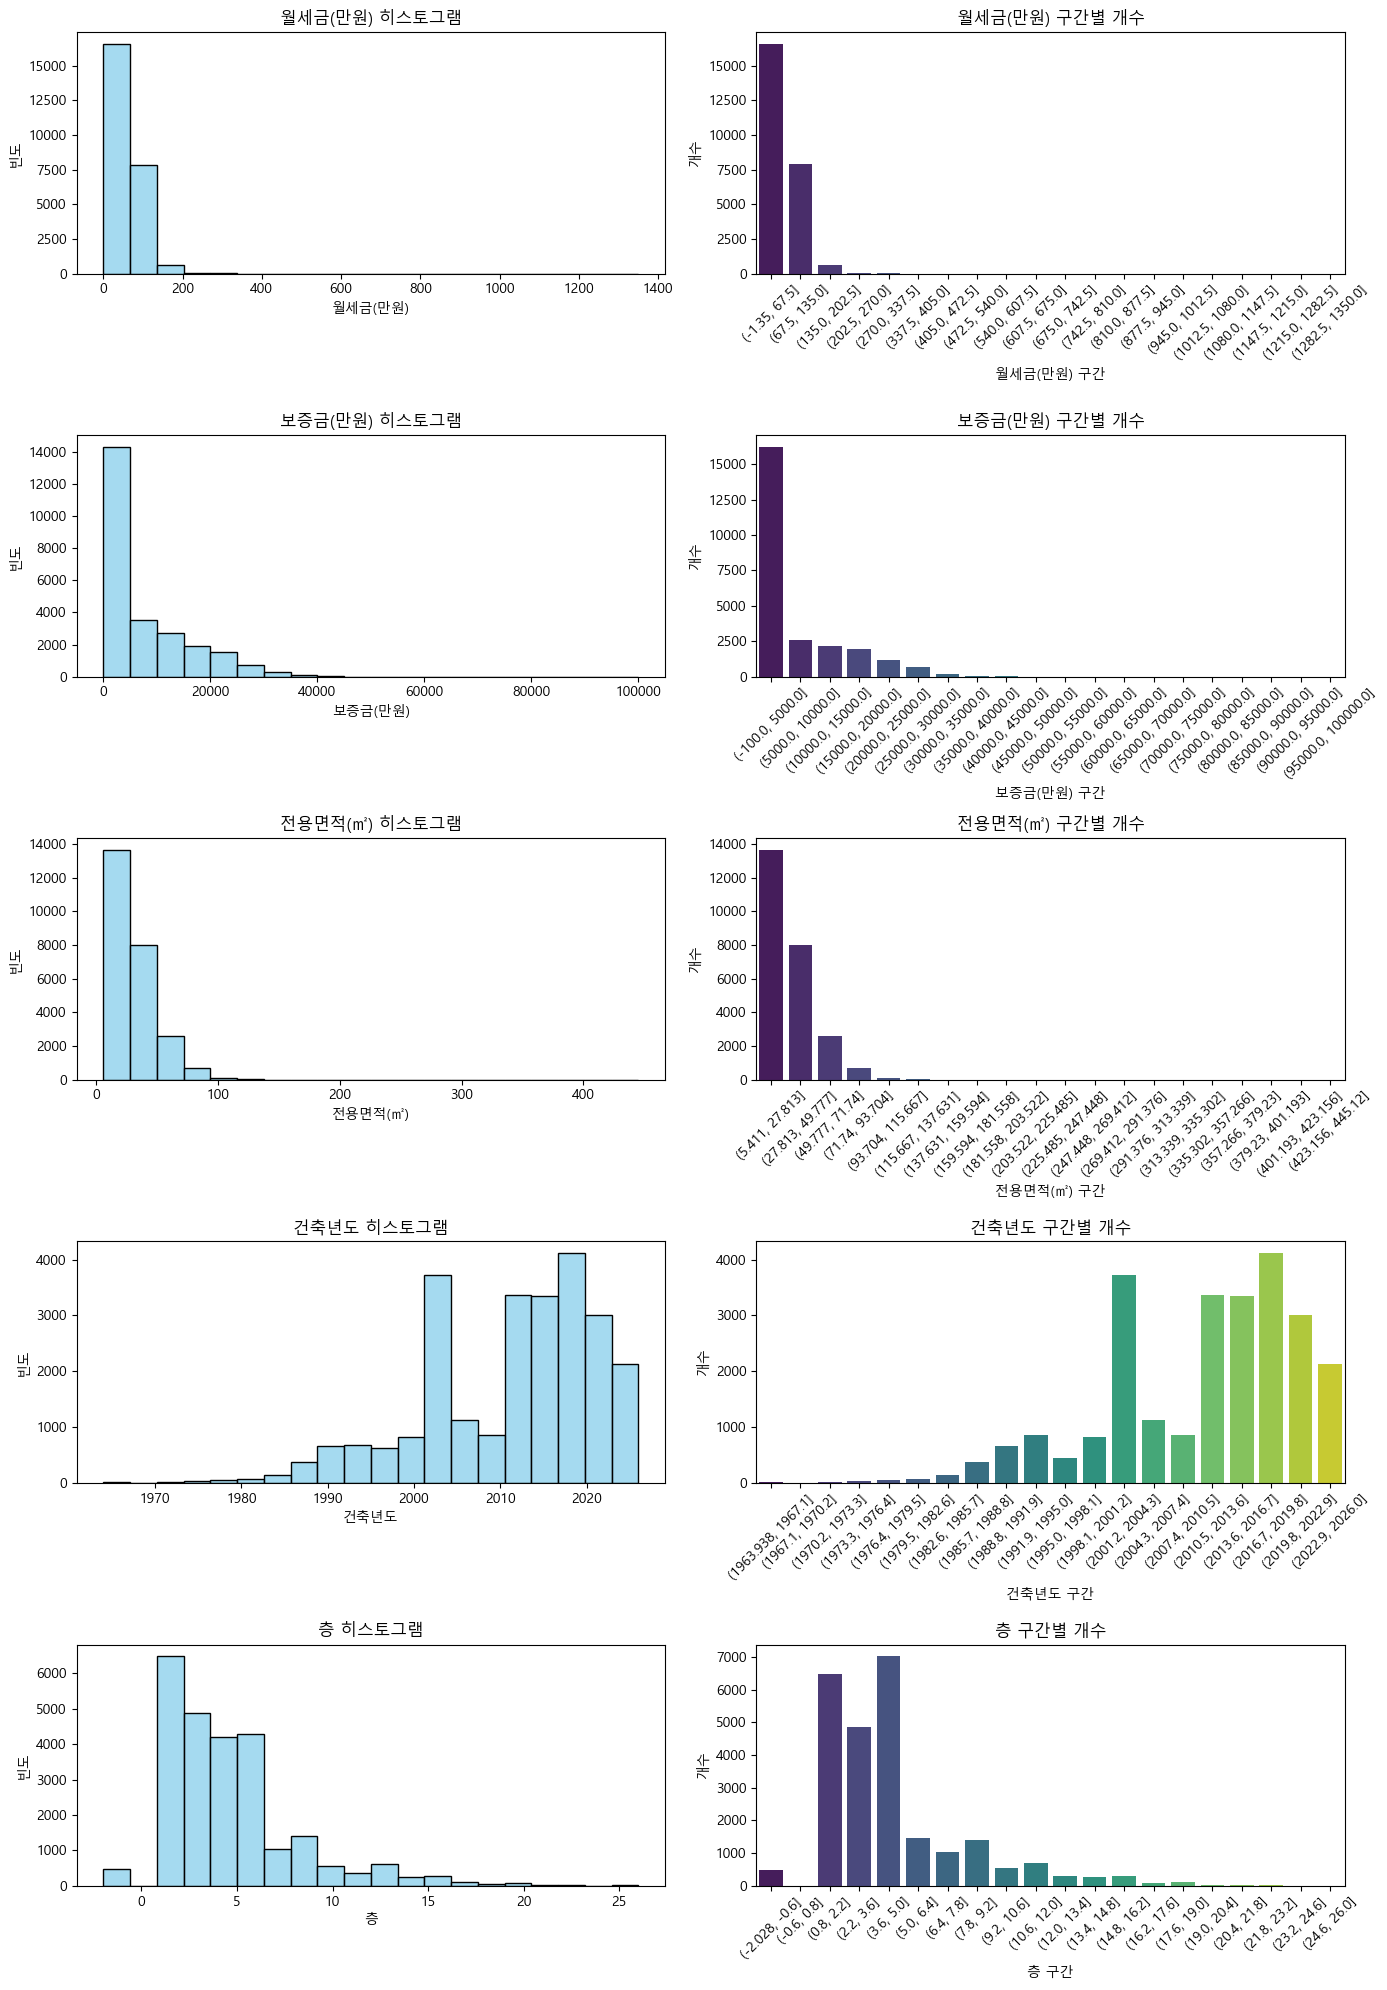

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

visual_cols = ['월세금(만원)', '보증금(만원)', '전용면적(㎡)', '건축년도', '층']

bin_settings = {
    '월세금(만원)': 20,
    '보증금(만원)': 20,
    '전용면적(㎡)': 20,
    '건축년도': 20,
    '층': 20
}

fig, axes = plt.subplots(len(visual_cols), 2, figsize=(14, 4 * len(visual_cols)))
for i, col in enumerate(visual_cols):
    if col not in df.columns:
        continue

    series = pd.to_numeric(df[col], errors='coerce').dropna()
    if series.empty:
        continue

    n_bins = bin_settings.get(col, 6)
    binned = pd.cut(series, bins=n_bins, duplicates='drop')
    df[f'{col}_구간'] = binned

    sns.histplot(series, bins=n_bins, kde=False, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col} 히스토그램')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('빈도')

    count_data = binned.value_counts().sort_index()
    sns.barplot(x=count_data.index.astype(str), y=count_data.values, ax=axes[i, 1], palette='viridis')
    axes[i, 1].set_title(f'{col} 구간별 개수')
    axes[i, 1].set_xlabel(f'{col} 구간')
    axes[i, 1].set_ylabel('개수')
    axes[i, 1].tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.show()

* 시각화만으로 값들의 평균이나 분산을 알 수 없기에 이는 따로 통계를 출력함  

In [16]:
important_cols = ['월세금(만원)', '보증금(만원)', '전용면적(㎡)', '건축년도', '층']

# 숫자형으로 안전하게 변환 후 통계 계산
stats_df = df[important_cols].apply(pd.to_numeric, errors='coerce')

print("기본 통계 정보:")
print(stats_df.describe())

print("\n평균, 표준편차, 중앙값:")
print(stats_df.agg(['mean', 'std', 'median']))

기본 통계 정보:
            월세금(만원)        보증금(만원)       전용면적(㎡)          건축년도             층
count  25147.000000   25147.000000  25147.000000  25147.000000  25147.000000
mean      57.147533    6943.789279     31.104314   2011.131109      4.580268
std       38.137412    8207.487838     18.746219      9.856524      3.451270
min        0.000000       0.000000      5.850000   1964.000000     -2.000000
25%       30.000000    1000.000000     18.120000   2003.000000      2.000000
50%       55.000000    3000.000000     26.430000   2014.000000      4.000000
75%       75.000000   10500.000000     38.820000   2019.000000      5.000000
max     1350.000000  100000.000000    445.120000   2026.000000     26.000000

평균, 표준편차, 중앙값:
          월세금(만원)      보증금(만원)    전용면적(㎡)         건축년도         층
mean    57.147533  6943.789279  31.104314  2011.131109  4.580268
std     38.137412  8207.487838  18.746219     9.856524  3.451270
median  55.000000  3000.000000  26.430000  2014.000000  4.000000


In [17]:
print("\n분산:")
print(stats_df.var())


분산:
월세금(만원)    1.454462e+03
보증금(만원)    6.736286e+07
전용면적(㎡)    3.514207e+02
건축년도       9.715107e+01
층          1.191127e+01
dtype: float64


### 이상치 분포 시각화 (Box Plot) 및 이상치 처리 

* 시각화와 각 컬럼변수에 대한 통계를 관찰한 결과 
    > 
    - 각 이상치들이 조금이지만 존재한다는 것을 알 수 있었다. 
    - 전용면적과 보증금의 부분에서 이상치가 심각하여 학생들을 위한 데이터를 만들때 노이즈로 적용될 수 있다. 
    - 이상치가 얼마나 분포하는지 모르기에 먼저 시각화를 해보고 이를 IQR방식으로 노이즈를 제거하려고 한다. 

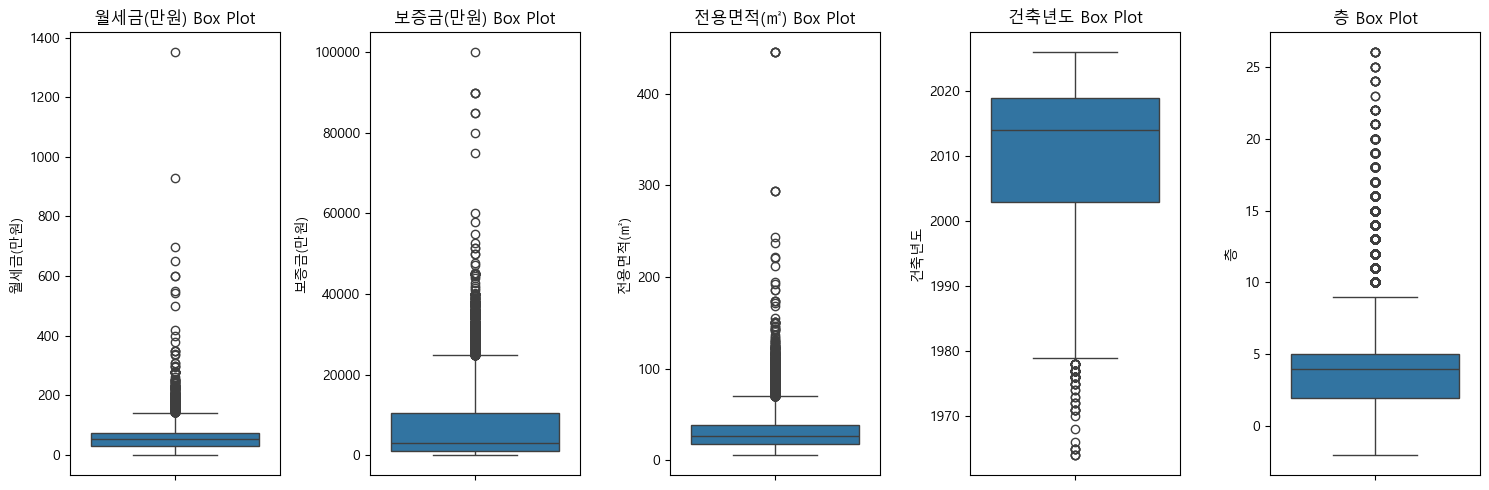

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Box plots for outlier detection
fig, axes = plt.subplots(1, len(important_cols), figsize=(15, 5))
for i, col in enumerate(important_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'{col} Box Plot')
plt.tight_layout()
plt.show()

#### BOX plot 결과 해석
> 데이터 자체가 망가진거라기 보다, 부동산 시장 자체가 이런 데이터 양상을 띄는 경우가 많다. 하지만 우리의 프로젝트는 학생들을 위한 데이터이기에 이러한 이상치들을 없애줘야 한다.

> 그리고 데이터를 처리하는 과정에서 월세인 데이터만 뽑았지만 여기에는 반전세, 준전세 같은 거래가 포함되어 있을 수 있기 때문에 이를 노이즈로 보고 처리를 해야 한다.


#### 1. 월세 box plot 분석
* 월세금(만원) box plot은 전체 분포가 한쪽으로 치우치고, 상위쪽에 극단적인 값들이 존재함을 보여준다.
* 이 점은 일부 고가·고층·신축 매물이 포함되어 있는 경우로 해석되며, 학생 대상 월세 예측 모델에서는 과도한 고가값이 영향을 주지 않도록 제거가 필요하다.
* 또한 상자 내부의 중앙값과 사분위 범위를 확인하면 일반적인 대학가 월세 수준과의 차이를 더 명확히 판단할 수 있다.

#### 2. 보증금 box plot 분석
* 보증금(만원) box plot에서는 매우 낮은 값과 매우 높은 값이 동시에 나타나며, 중간값과 상자 범위가 넓은 편이다.
* 이는 보증금이 0원에 가까운 반전세·준전세 거래나, 높은 보증금의 전세 전환 사례가 혼재된 결과로 보인다.
* 학생 전월세 분석에서는 이러한 극단치가 월세와의 관계를 왜곡할 수 있으므로, 필요 시 보증금 범위를 제한하거나 별도 처리해야 한다.

#### 3. 전용면적 box plot 분석
* 전용면적(㎡) box plot은 대부분 소형 평수에 집중되지만, 일부 넓은 평수 대가 이상치로 나타난다.
* 대학가 월세 시장의 특성을 고려하면 20~30㎡ 내외가 주요 범위이며, 이를 벗어나면 학생용 주거처로서 대표성이 떨어질 수 있다.
* 따라서 모델링 전에는 일반적인 면적 범위대로 데이터를 제한하여 학생 맞춤 분석에 적합한 샘플만 남기는 것이 좋다.

#### 4. 건축년도 box plot 분석
* 건축년도 box plot에서는 비교적 최근 건물들이 집중되지만, 오래된 건물과 매우 신축 건물이 함께 존재한다.
* 오래된 건물의 낮은 임대료와 신축 건물의 높은 임대료가 혼재되면 건축년도 변수의 효과가 불분명해질 수 있다.
* 학생 대상 월세 예측에서는 적절한 연식 범위를 설정하거나, 건축년도를 범주형으로 재코딩해 노이즈를 줄이는 것이 도움이 된다.

## 아웃라이어 처리 

In [19]:
Q1 = df['월세금(만원)'].quantile(0.25)
Q3 = df['월세금(만원)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[(df['월세금(만원)'] >= lower) & (df['월세금(만원)'] <= upper)]

## 거리 feature 만들기

In [20]:
universities = { # 주요 학교 5개의 위도 , 경도 좌표 받아오기 
    '서울대': (37.4599, 126.9519),
    '숭실대': (37.4963, 126.9574),
    '고려대': (37.5894, 127.0324),
    '연세대': (37.5658, 126.9386),
    '건국대': (37.5408, 127.0793)
}

## Geocoding
주소 → 위경도 변환
방법:

Kakao Developers

회원가입 → REST API key 발급

* 주소 -> 위경도 변환 하기전 주소만들기 

In [26]:
df["도로명주소"] = df["시군구"] + " " + df["도로명"] 

In [40]:
import requests ### 카카오 API받아오기 
from dotenv import load_dotenv
import os

load_dotenv()
KakaoAPI = os.getenv("KakaoAPI")
print(f"Kakao API Key: {KakaoAPI[:5]}...")  # API 키의 앞부분만 출력하여 확인

# 도로명주소를 이용해서 위도 경도 좌표 받아오기 (카카오 API)
# 일단 하나씩 변환하기 ( 테스트 용 )
def geocode(address):
    url = "https://dapi.kakao.com/v2/local/search/address.json"

    # "KakaoAK " 접두사 자동 추가
    if not KakaoAPI.startswith("KakaoAK"):
        auth_header = f"KakaoAK {KakaoAPI}"
    else:
        auth_header = KakaoAPI

    headers = {
        "Authorization": auth_header
    }

    params = {
        "query": address
    }

    res = requests.get(url, headers=headers, params=params)

    data = res.json()

    if res.status_code != 200:
        print(f"에러 응답: {res.text}")  # 상세 에러 메시지 확인
        return None
    
    data = res.json()
    if data.get('documents'):
        x = float(data['documents'][0]['x'])
        y = float(data['documents'][0]['y'])
        return y, x
    return None

Kakao API Key: 3f192...


In [41]:
# 좌표 변환 테스트 
test_address = df["도로명주소"].iloc[0]
print(f"테스트 주소: {test_address}")

test_coords = geocode(test_address)
print(f"테스트 주소 좌표: {test_coords}")

테스트 주소: 서울특별시 광진구 구의동 자양로22길 45
테스트 주소 좌표: (37.5397969820178, 127.085961402919)


## 거리계산

In [22]:
### 거리계산 후 특징 추가 

## 가설검정 

### 가설 설정
> #### 1. 대학가별 평균 월세는 차이가 있다 
> * 영가설 H₀ : 각 대학가(관악구, 동작구, 성북구…)의 평균 월세는 동일하다.
> * 대립가설 H₁ : 적어도 한 대학가의 평균 월세는 다르다.
> * → 일원분산분석 (ANOVA) 사용
> * → 추가적으로 어디가 어떻게 다른지 확인을 위해 사후검정 turky-hsd 사용 

> #### 2. 대학까지 거리가 가까울수록 월세가 높다 (추가적인 특징 검정)
> * 영가설 H₀ : 대학까지 거리와 월세는 관련이 없다.
> * 대립가설 H₁ : 대학까지 거리가 가까울수록 월세가 높다.
> * → 상관분석 (Pearson correlation) 사용

> #### 3. 면적이 넓을수록 월세가 높다. (기본관계)
> * 영가설 H₀ : 면적과 월세는 관련이 없다.
> * 대립가설 H₁ : 면적이 넓을수록 월세가 높다.
> * → 상관분석 (Pearson correlation) 사용

> #### 4. 건축년도가 최신일수록 월세가 높다 (기본관계)  
> * 영가설 H₀ : 건축년도와 월세는 관련이 없다.
> * 대립가설 H₁ : 건축년도가 최신일수록 월세가 높다.
> * → 상관분석 (Pearson correlation) 사용

> #### 5. 보증금이 높을수록 월세는 낮다. (trade off관계)  
> * 영가설 H₀ : 보증금과 월세는 관련이 없다.
> * 대립가설 H₁ : 보증금이 높아질수록 월세가 낮아진다.
> * → 상관분석 (Pearson correlation) 사용 <방향성까지 봄>

## EDA (분석 및 시각화)

## 모델링

In [23]:
# 변수를 선택을 할 때 다분공산성도 한번 체크를 함 
# 최대한 독립변수만 남겨서 예측모델을 만들어야함 

In [24]:
# 예측 모델 생성전 특징 최적화 필요함 
# PCA나 LDA같은 차원축소 기법도 한번 써보는 것도 좋음 
# -> 왜냐면 가장 설명을 잘하는 변수를 뽑아서 예측모델을 만들어야하기 때문임

# 예측을 하기전에 표준화 필수임 
# 샘플링 단계에서 클래스 수 맞춰줘야함 
# 오버샘플링은 따로 하지 않음 


## 평가 및 검증